In [34]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [35]:
# Importing necessary libraries
import pandas as pd # data manipulation
import numpy as np # numerical python
import matplotlib.pyplot as plt #(graph) visualizattion

In [36]:
#load the dataset
df = pd.read_csv(r"C:\Users\Swamy K R\Downloads\appliance_energy.csv")
df.head()

,Temperature (°C),Energy Consumption (kWh)
0,22.490802,2.292604
1,34.014286,3.251925
2,29.639879,3.009868
3,26.973170,1.703533
4,18.120373,1.702201


In [37]:
df.tail()

,Temperature (°C),Energy Consumption (kWh)
95,24.875912,2.079686
96,25.454657,2.506915
97,23.550820,2.525658
98,15.508383,1.689184
99,17.157829,2.129374


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature (°C)          100 non-null    float64
 1   Energy Consumption (kWh)  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [39]:
df.describe()

,Temperature (°C),Energy Consumption (kWh)
count,100.000000,100.000000
mean,24.403615,2.439821
std,5.949788,0.693527
min,15.110442,0.978107
25%,18.864015,1.908640
50%,24.282849,2.364121
75%,29.604062,2.931199
max,34.737739,4.159094


In [40]:
df.isnull()

,Temperature (°C),Energy Consumption (kWh)
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
95,False,False
96,False,False
97,False,False
98,False,False


In [41]:
# how find rows and culomns
df.shape

(100, 2)

In [42]:
df.isnull().sum()

Temperature (°C)            0
Energy Consumption (kWh)    0
dtype: int64

In [43]:
# how find the duplicated function
df.duplicated().sum()

np.int64(0)

In [44]:
#feature and target selection
x = df[['Temperature (°C)']]
y = df['Energy Consumption (kWh)']

In [45]:
x.shape

(100, 1)

In [46]:
y.shape

(100,)

In [47]:
# import Ml
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [48]:
# split it to trian test
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8, random_state=42)

In [49]:
x_train.shape

(80, 1)

In [50]:
x_test.shape

(20, 1)

In [51]:
y_test.shape

(20,)

In [52]:
y_train.shape

(80,)

In [53]:
# Instantiate the model
model = LinearRegression()

In [54]:
#
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
# prediction
y_pred = model.predict(x_test)
print(f'The model prediction are\n{y_pred}')

The model prediction are
[1.6858187  3.18154068 2.96097494 2.76354868 2.0370856  2.36343345
 2.09711944 3.12445907 1.60849483 2.24537556 2.34866555 2.66462648
 3.0387357  3.27880886 1.78664542 1.85218469 2.95922164 1.70468695
 3.0692904  1.87828475]


In [56]:
len(y_pred)

20

In [57]:
#evaluate the model
mse = mean_squared_error(y_test, y_pred)
mse

0.16342487842925052

In [58]:
r2 = r2_score(y_test, y_pred)
r2

0.6119478445218715

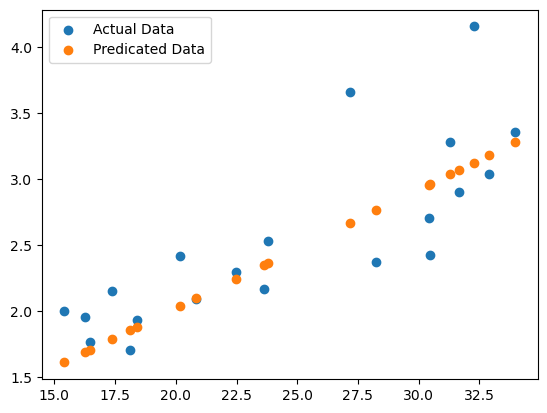

In [59]:
plt.scatter(x_test, y_test, label='Actual Data')
plt.scatter(x_test, y_pred, label='Predicated Data')
plt.legend()

In [60]:
# To save the model
import joblib
joblib.dump(model,'LR_Model.pkl')

['LR_Model.pkl']

In [61]:
joblib.load('LR_Model.pkl')

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
# Importing necessary libraries
import pandas as pd # data manipulation
import numpy as np # numerical python
import matplotlib.pyplot as plt #(graph) visualizattion

In [63]:
# load the data set - sns
import seaborn as sns
from sklearn.datasets import load_iris

In [64]:
data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [65]:
# feature and target selection
x = data.data
y = data.target

In [68]:
xtr,xte,ytr,yte = train_test_split(x,y,test_size=0.2, random_state=16)

In [69]:
xtr.shape

(120, 4)

In [70]:
ytr.shape

(120,)

In [71]:
# standardization - scaling
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [72]:
xtr_scaled = ss.fit_transform(xtr)
xtr_scaled

array([[ 1.01598333, -0.15128216,  0.80258614,  1.41151006],
       [ 0.77360162, -0.15128216,  1.13953192,  1.28121682],
       [-1.89259719, -0.15128216, -1.49987671, -1.45494114],
       [ 0.2888382 , -0.61676571,  0.52179798, -0.02171554],
       [-0.68068864,  1.4779103 , -1.27524619, -1.3246479 ],
       [-0.55949778, -0.15128216,  0.40948272,  0.36916417],
       [-1.28664291,  0.77968496, -1.21908856, -1.3246479 ],
       [-0.07473436, -1.08224927,  0.12869457, -0.02171554],
       [ 1.74312846, -0.38402394,  1.42032007,  0.76004388],
       [-1.0442612 ,  0.3142014 , -1.44371908, -1.3246479 ],
       [ 1.13717419, -0.15128216,  0.97105903,  1.15092359],
       [ 2.47027359,  1.71065207,  1.4764777 ,  1.02063035],
       [-1.0442612 ,  0.54694318, -1.33140382, -1.3246479 ],
       [ 0.41002906, -2.01321639,  0.40948272,  0.36916417],
       [-0.31711607, -0.15128216,  0.40948272,  0.36916417],
       [ 0.04645649, -0.15128216,  0.7464285 ,  0.76004388],
       [ 1.25836504,  0.

In [73]:
# algo- logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [74]:
# instantiate the LR class
lr_model = LogisticRegression()
lr_model.fit(xtr_scaled, ytr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
# prediction 
lr_pred = lr_model.predict(xte)

In [76]:
lr_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2])

In [78]:
# evalution 
acc = accuracy_score(yte, lr_pred)
print(f'The accuracy score is {acc*100}')

The accuracy score is 26.666666666666668


# 
cm = confusion_matrix(yte, lr_pred)
cm

In [79]:
from sklearn.tree import DecisionTreeClassifier

In [80]:
df = pd.read_csv(r"C:\Users\Swamy K R\Downloads\Renewable_Energy_Adoption.csv")
df.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,adoption
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


In [81]:
df.shape

(100, 5)

In [82]:
df.columns

Index(['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency', 'adoption'],
      dtype='object')

In [83]:
# features and target selection
x = df[['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency']]
y = df['adoption']

In [84]:
# train test split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

In [85]:
# instantiate the model
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [86]:
# train the model 
model.fit(xtrain, ytrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [87]:
# predict 
y_pred = model.predict(xtest)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [88]:
# evaluate the model
acc = accuracy_score(ytest, y_pred)
print(f'the accuracy score dtc is {acc*100}')

the accuracy score dtc is 85.0


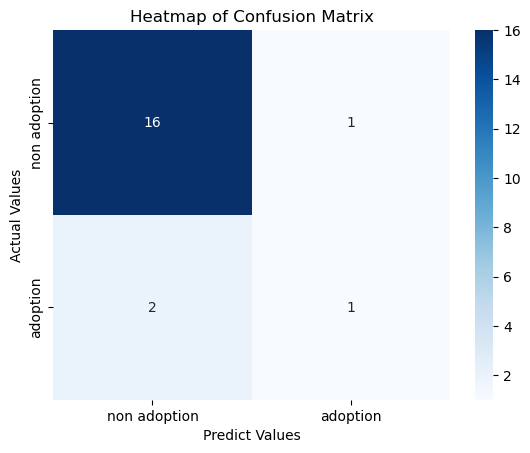

In [89]:
cm = confusion_matrix(ytest, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues',
           xticklabels=['non adoption', 'adoption'],
           yticklabels=['non adoption', 'adoption'])
plt.title('Heatmap of Confusion Matrix')
plt.xlabel('Predict Values')
plt.ylabel('Actual Values')
plt.show()

In [90]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

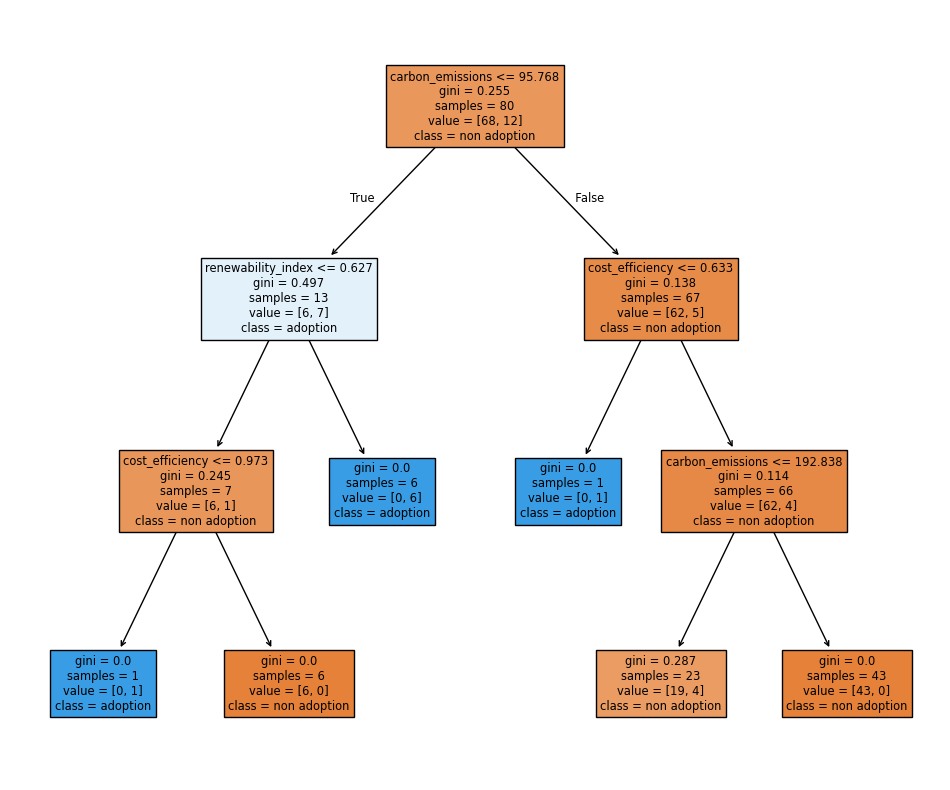

In [91]:
plt.figure(figsize=(12, 10))
plot_tree(model, filled=True, feature_names=xtrain.columns,
          class_names=['non adoption','adoption'])
plt.show()

In [92]:
cr = classification_report(ytest, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       0.50      0.33      0.40         3

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20

